In [10]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

In [15]:
DATA_DIR="/kaggle/input/fdsdfdsdfg/faces_split/faces_split"
def count_images(split):
    real_count,fake_count=0,0
    split_path=os.path.join(DATA_DIR,split)
    for folder in os.listdir(os.path.join(split_path,"real")):
        real_count+=len(os.listdir(os.path.join(split_path,"real",folder)))
    for folder in os.listdir(os.path.join(split_path,"fake")):
        fake_count+=len(os.listdir(os.path.join(split_path,"fake",folder)))
    return real_count,fake_count
for split in ["train","val","test"]:
    real, fake=count_images(split)
    print(f"{split.upper()} → Real: {real}, Fake: {fake}")

TRAIN → Real: 148345, Fake: 148366
VAL → Real: 32223, Fake: 32130
TEST → Real: 33316, Fake: 32802


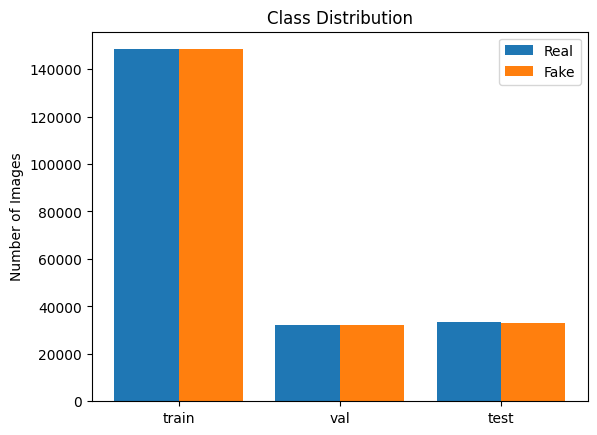

In [16]:
splits=["train","val","test"]
real_counts=[]
fake_counts=[]
for s in splits:
    r,f=count_images(s)
    real_counts.append(r)
    fake_counts.append(f)
x=np.arange(len(splits))
plt.bar(x - 0.2,real_counts,width=0.4,label="Real")
plt.bar(x + 0.2,fake_counts,width=0.4,label="Fake")
plt.xticks(x,splits)
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.legend()
plt.show()


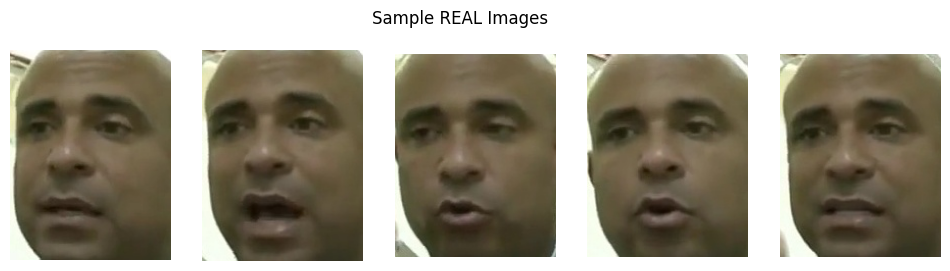

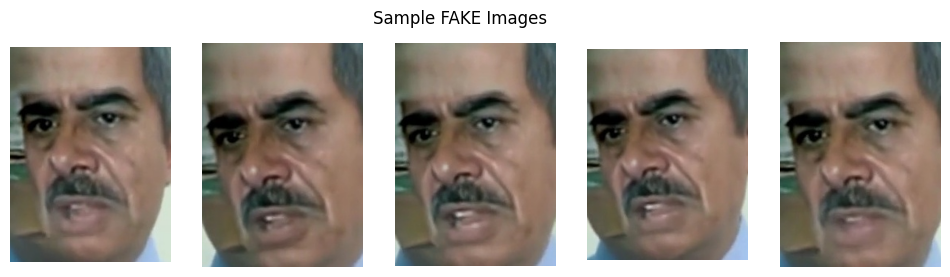

In [17]:
def show_samples(class_name):
    path=os.path.join(DATA_DIR,"train",class_name)
    folder=random.choice(os.listdir(path))
    images=os.listdir(os.path.join(path,folder))[:5]
    plt.figure(figsize=(12,3))
    for i, img in enumerate(images):
        image=Image.open(os.path.join(path,folder,img))
        plt.subplot(1,5,i+1)
        plt.imshow(image)
        plt.axis("off")
    plt.suptitle(f"Sample {class_name.upper()} Images")
    plt.show()
show_samples("real")
show_samples("fake")

In [18]:
sizes=[]
for cls in ["real","fake"]:
    cls_path=os.path.join(DATA_DIR,"train",cls)
    folder=random.choice(os.listdir(cls_path))
    for img in os.listdir(os.path.join(cls_path,folder))[:50]:
        image=Image.open(os.path.join(cls_path,folder,img))
        sizes.append(image.size)
sizes=np.array(sizes)
print("Average Width:",sizes[:,0].mean())
print("Average Height:",sizes[:,1].mean())

Average Width: 136.76
Average Height: 192.38
